# 01 — Corpus exploration

## Goal

This notebook explores the structure of the Corpus Chapitres before any preprocessing is performed. It identifies the corpus organisation, inspects the XML structure, extracts bibliographic metadata, performs basic quality control, and generates descriptive statistics used in Chapter 3.

No modifications are made to the original XML files.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Project organisation

In [2]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/SemanticChangeThesis")

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
METADATA_DIR = DATA_DIR / "metadata"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
SCRIPTS_DIR = PROJECT_DIR / "scripts"
MODELS_DIR = PROJECT_DIR / "models"

for folder in [
    RAW_DIR,
    METADATA_DIR,
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    NOTEBOOKS_DIR,
    SCRIPTS_DIR,
    MODELS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders ready.")
print(PROJECT_DIR)

Project folders ready.
/content/drive/MyDrive/SemanticChangeThesis


## 3. Locating the corpus

In [3]:
print("Files in raw folder:")
for file in RAW_DIR.iterdir():
    print(file.name)

Files in raw folder:
ANRChapitres-2000romans19e20e-ea770e4


In [4]:
corpus_folder = RAW_DIR / "ANRChapitres-2000romans19e20e-ea770e4"

xml_files = sorted(corpus_folder.glob("*.xml"))

print(f"Number of XML files: {len(xml_files)}")
print("\nFirst five files:\n")

for file in xml_files[:5]:
    print(file.name)

Number of XML files: 2030

First five files:

1811_Chateaubriand-François-Rene-de_Oeuvres-completes.xml
1812_Kock-Paul-de_L-enfant-de-ma-femme.xml
1815_Gay-Sophie_Anatole_Vol-1.xml
1815_Gay-Sophie_Anatole_Vol-2.xml
1816_Barthelemy-Hadot-Marie-Adelaide_La-Vierge-de-l-Indostan-ou-les-Portugais-au-Malabar_(Tome-1).xml


## 4. Inspecting the XML structure

Before extracting metadata automatically, several XML files are inspected to verify that the corpus follows a consistent TEI-XML structure.

In [5]:
with open(xml_files[0], "r", encoding="utf-8") as f:
    for _ in range(80):
        print(f.readline(), end="")

<?xml version='1.0' encoding='UTF8'?>
<TEI>
  <teiHeader>
    <fileDesc>
      <titleStmt>
        <title> Oeuvres complètes de Chateaubriand. augmentées d'un essai sur la vie et les ouvrages de l'auteur / [par Delandine de Saint-Esprit] - Volume 7 (1851-1852) </title>
        <author from="1768" key="" name="Chateaubriand, François-René de" sex="male" to="1848"/>
        <edition n=""/>
        <editor name="Krabbe" where="Paris"/>
      </titleStmt>
      <publicationStmt>
        <date type="created" when="1811"/>
        <date type="issued" when="1851"/>
      </publicationStmt>
      <editionStmt>
        <profileDesc tag="canon" type="genre">
          <textClass>
            <keywords>
              <term>récit de voyage</term>
            </keywords>
          </textClass>
        </profileDesc>
      </editionStmt>
    </fileDesc>
  </teiHeader>
  <text>
    <front>
      <titlePage>
        <docAuthor/>
        <docTitle>
          <titlePart main="Oeuvres complètes de Chatea

## 5. Metadata extraction

The metadata are extracted from the TEI header of each XML file. The extracted fields include the file name, title, author, author birth and death dates, author sex, publication year, and available genre labels.

In [6]:
import re
import pandas as pd
from tqdm.auto import tqdm

def read_header_only(xml_path, max_chars=20000):
    with open(xml_path, "r", encoding="utf-8") as f:
        text = f.read(max_chars)

    if "</teiHeader>" in text:
        text = text.split("</teiHeader>")[0] + "</teiHeader>"

    return text

def extract_metadata_fast(xml_path):
    header = read_header_only(xml_path)

    def find(pattern):
        match = re.search(pattern, header, flags=re.DOTALL)
        return match.group(1).strip() if match else None

    title = find(r"<title>(.*?)</title>")
    author = find(r'<author[^>]*name="([^"]*)"')
    author_birth = find(r'<author[^>]*from="([^"]*)"')
    author_death = find(r'<author[^>]*to="([^"]*)"')
    author_sex = find(r'<author[^>]*sex="([^"]*)"')
    publication_year = find(r'<date[^>]*type="created"[^>]*when="([^"]*)"')

    terms = re.findall(r"<term>(.*?)</term>", header, flags=re.DOTALL)
    terms = [t.strip() for t in terms]

    return {
        "file": xml_path.name,
        "title": title,
        "author": author,
        "author_birth": author_birth,
        "author_death": author_death,
        "author_sex": author_sex,
        "publication_year": publication_year,
        "genres": "; ".join(terms) if terms else None,
    }

metadata = [extract_metadata_fast(path) for path in tqdm(xml_files)]
metadata_df = pd.DataFrame(metadata)

metadata_df.to_csv(METADATA_DIR / "metadata_raw.csv", index=False, encoding="utf-8")

metadata_df.head()

  0%|          | 0/2030 [00:00<?, ?it/s]

,file,title,author,author_birth,author_death,author_sex,publication_year,genres
0,1811_Chateaubriand-François-Rene-de_Oeuvres-c...,Oeuvres complètes de Chateaubriand. augmentées...,"Chateaubriand, François-René de",1768,1848,male,1811,récit de voyage
1,1812_Kock-Paul-de_L-enfant-de-ma-femme.xml,L'enfant de ma femme,"Kock, Paul de",1793,1871,male,1812,None
2,1815_Gay-Sophie_Anatole_Vol-1.xml,"Anatole, Vol. 1","Gay, Sophie",1776,1852,female,1815,None
3,1815_Gay-Sophie_Anatole_Vol-2.xml,"Anatole, Vol. 2","Gay, Sophie",1776,1852,female,1815,None
4,1816_Barthelemy-Hadot-Marie-Adelaide_La-Vierge...,"La Vierge de l'Indostan, ou les Portugais au M...","Barthélemy-Hadot, Marie-Adélaïde",1763,1821,female,1816,roman historique


## 6. Metadata validation and quality control

The extracted metadata are checked before being used for temporal segmentation. The raw publication year is preserved, and corrected values are stored separately to maintain an audit trail.

In [7]:
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   file              2030 non-null   object
 1   title             2030 non-null   object
 2   author            2030 non-null   object
 3   author_birth      2030 non-null   object
 4   author_death      2030 non-null   object
 5   author_sex        2030 non-null   object
 6   publication_year  2030 non-null   object
 7   genres            1374 non-null   object
dtypes: object(8)
memory usage: 127.0+ KB


In [8]:
metadata_quality = pd.DataFrame({
    "field": ["file", "title", "author", "author_birth", "author_death", "author_sex", "publication_year", "genres"],
    "missing_values": [
        metadata_df["file"].isna().sum(),
        metadata_df["title"].isna().sum(),
        metadata_df["author"].isna().sum(),
        metadata_df["author_birth"].isna().sum(),
        metadata_df["author_death"].isna().sum(),
        metadata_df["author_sex"].isna().sum(),
        metadata_df["publication_year"].isna().sum(),
        metadata_df["genres"].isna().sum(),
    ],
    "available_values": [
        metadata_df["file"].notna().sum(),
        metadata_df["title"].notna().sum(),
        metadata_df["author"].notna().sum(),
        metadata_df["author_birth"].notna().sum(),
        metadata_df["author_death"].notna().sum(),
        metadata_df["author_sex"].notna().sum(),
        metadata_df["publication_year"].notna().sum(),
        metadata_df["genres"].notna().sum(),
    ],
})

metadata_quality.to_csv(TABLES_DIR / "metadata_quality.csv", index=False, encoding="utf-8")
metadata_quality

,field,missing_values,available_values
0,file,0,2030
1,title,0,2030
2,author,0,2030
3,author_birth,0,2030
4,author_death,0,2030
5,author_sex,0,2030
6,publication_year,0,2030
7,genres,656,1374


In [10]:
metadata_df["publication_year_raw"] = metadata_df["publication_year"]
metadata_df["publication_year_corrected"] = metadata_df["publication_year"]
metadata_df["date_correction_note"] = ""

A small number of publication years were found to be incorrect in the TEI metadata. These were corrected manually after verification. The original values are preserved in `publication_year_raw`, while the corrected values are stored in `publication_year_corrected`.

In [11]:
manual_date_corrections = {
    "1838_Gautier-Theophile_Fortunio.xml": 1838,
    "1860_Vie-Anduze-Henri_Dernier-amour-de-Cinq-Mars-roman-historique.xml": 1860,
    "1910_Ivoi-Paul-d-_Millionnaire-malgre-lui_tome-2.xml": 1910,
    "1935_Delly_Contes.xml": 1935
}

for filename, correct_year in manual_date_corrections.items():
    mask = metadata_df["file"] == filename
    metadata_df.loc[mask, "publication_year_corrected"] = correct_year
    metadata_df.loc[mask, "date_correction_note"] = "Corrected manually after metadata validation"

metadata_df[metadata_df["date_correction_note"] != ""]

,file,title,author,author_birth,author_death,author_sex,publication_year,genres,publication_year_raw,publication_year_corrected,date_correction_note
118,1838_Gautier-Theophile_Fortunio.xml,Fortunio,"Gautier, Théophile",1811,1872,male,2013,None,2013,1838,Corrected manually after metadata validation
509,1860_Vie-Anduze-Henri_Dernier-amour-de-Cinq-Ma...,"Dernier amour de Cinq-Mars, roman historique","Vié-Anduze, Henri",1???,1???,male,2013,roman historique,2013,1860,Corrected manually after metadata validation
1661,1910_Ivoi-Paul-d-_Millionnaire-malgre-lui_tome...,Millionnaire malgré lui (tome 2),"Deleutre, Paul dit Ivoi, Paul d'",1856,1915,male,2013,roman d'aventures,2013,1910,Corrected manually after metadata validation
1920,1935_Delly_Contes.xml,Contes,"Petitjean de la Rosière, Jeanne-Marie",1875,1947,female,19XX,nouvelles; roman sentimental,19XX,1935,Corrected manually after metadata validation


In [12]:
metadata_audit = metadata_df.copy()

metadata_final = metadata_df.copy()
metadata_final["publication_year"] = metadata_final["publication_year_corrected"]

columns_to_keep = [
    "file",
    "title",
    "author",
    "author_birth",
    "author_death",
    "author_sex",
    "publication_year",
    "genres",
]

metadata_final = metadata_final[columns_to_keep]

metadata_audit.to_csv(METADATA_DIR / "metadata_audit.csv", index=False, encoding="utf-8")
metadata_final.to_csv(METADATA_DIR / "metadata.csv", index=False, encoding="utf-8")


metadata_final.head()

,file,title,author,author_birth,author_death,author_sex,publication_year,genres
0,1811_Chateaubriand-François-Rene-de_Oeuvres-c...,Oeuvres complètes de Chateaubriand. augmentées...,"Chateaubriand, François-René de",1768,1848,male,1811,récit de voyage
1,1812_Kock-Paul-de_L-enfant-de-ma-femme.xml,L'enfant de ma femme,"Kock, Paul de",1793,1871,male,1812,None
2,1815_Gay-Sophie_Anatole_Vol-1.xml,"Anatole, Vol. 1","Gay, Sophie",1776,1852,female,1815,None
3,1815_Gay-Sophie_Anatole_Vol-2.xml,"Anatole, Vol. 2","Gay, Sophie",1776,1852,female,1815,None
4,1816_Barthelemy-Hadot-Marie-Adelaide_La-Vierge...,"La Vierge de l'Indostan, ou les Portugais au M...","Barthélemy-Hadot, Marie-Adélaïde",1763,1821,female,1816,roman historique


## 7. Corpus statistics

The following statistics are computed from the validated metadata table.

In [18]:
metadata_final["publication_year"] = pd.to_numeric(
    metadata_final["publication_year"],
    errors="coerce"
).astype("Int64")

In [19]:
all_genres = (
    metadata_final["genres"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

corpus_stats = pd.DataFrame({
    "statistic": [
        "Number of XML files",
        "Number of unique authors",
        "Earliest publication year",
        "Latest publication year",
        "Number of unique genre labels",
        "Missing publication years",
        "Missing authors",
        "Manually corrected publication years",
    ],
    "value": [
        len(metadata_final),
        metadata_final["author"].nunique(dropna=True),
        int(metadata_final["publication_year"].min()),
        int(metadata_final["publication_year"].max()),
        all_genres.nunique(),
        metadata_final["publication_year"].isna().sum(),
        metadata_final["author"].isna().sum(),
        (metadata_audit["date_correction_note"] != "").sum(),
    ],
})

corpus_stats.to_csv(TABLES_DIR / "corpus_statistics.csv", index=False, encoding="utf-8")
corpus_stats

,statistic,value
0,Number of XML files,2030
1,Number of unique authors,512
2,Earliest publication year,1811
3,Latest publication year,1968
4,Number of unique genre labels,19
5,Missing publication years,0
6,Missing authors,0
7,Manually corrected publication years,4


## 8. Temporal Distribution

The corpus is grouped by publication decade in order to assess whether decade-level temporal segmentation is suitable for the diachronic analysis.

In [20]:
metadata_final["decade"] = (
    metadata_final["publication_year"] // 10 * 10
).astype("Int64")

novels_per_decade = (
    metadata_final
    .dropna(subset=["decade"])
    .groupby("decade")
    .size()
    .reset_index(name="number_of_novels")
    .sort_values("decade")
)

novels_per_decade.to_csv(TABLES_DIR / "novels_per_decade.csv", index=False, encoding="utf-8")
novels_per_decade

,decade,number_of_novels
0,1810,17
1,1820,29
2,1830,85
3,1840,211
4,1850,157
5,1860,232
6,1870,285
7,1880,301
8,1890,201
9,1900,146


In [21]:
authors_per_decade = (
    metadata_final
    .dropna(subset=["decade"])
    .groupby("decade")["author"]
    .nunique()
    .reset_index(name="number_of_authors")
    .sort_values("decade")
)

authors_per_decade.to_csv(TABLES_DIR / "authors_per_decade.csv", index=False, encoding="utf-8")
authors_per_decade

,decade,number_of_authors
0,1810,6
1,1820,16
2,1830,37
3,1840,45
4,1850,54
5,1860,106
6,1870,134
7,1880,155
8,1890,92
9,1900,75


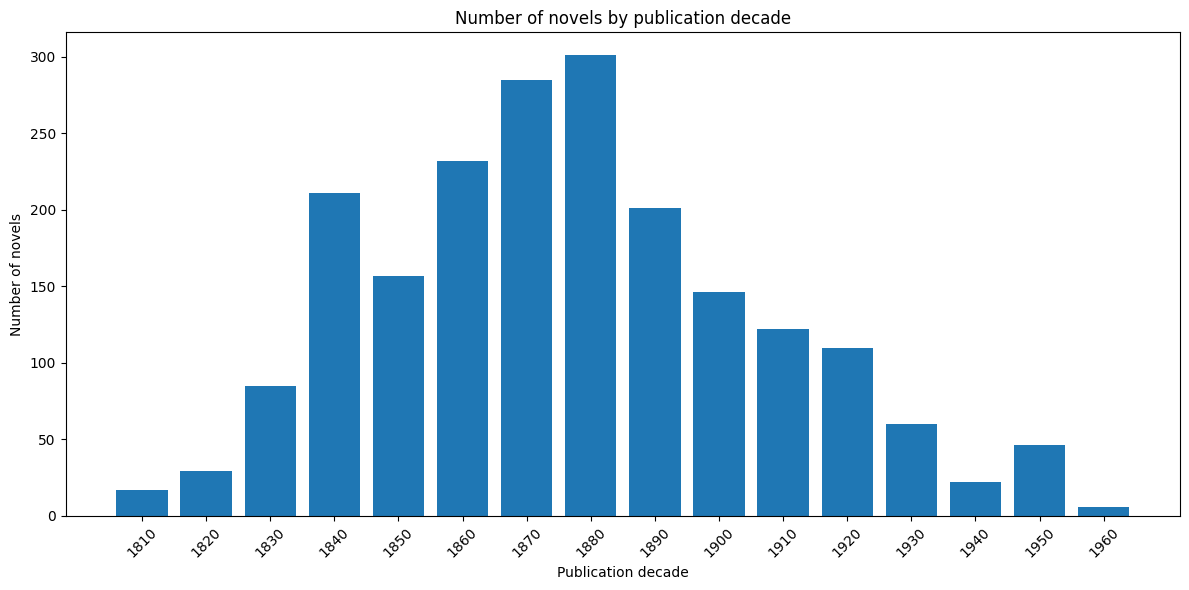

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    novels_per_decade["decade"].astype(str),
    novels_per_decade["number_of_novels"]
)

plt.xticks(rotation=45)
plt.xlabel("Publication decade")
plt.ylabel("Number of novels")
plt.title("Number of novels by publication decade")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "novels_per_decade.png", dpi=300, bbox_inches="tight")

plt.show()

## 9. Genre metadata

Genre annotations are not available for all works. The following statistics therefore describe only the annotated subset and should not be interpreted as a complete genre distribution for the entire corpus.

In [23]:
genre_summary = pd.DataFrame({
    "Category": [
        "Annotated with at least one genre",
        "No genre annotation",
    ],
    "Count": [
        metadata_final["genres"].notna().sum(),
        metadata_final["genres"].isna().sum(),
    ],
})

genre_summary["Percentage"] = (
    genre_summary["Count"] / len(metadata_final) * 100
).round(2)

genre_summary.to_csv(TABLES_DIR / "genre_metadata_summary.csv", index=False, encoding="utf-8")
genre_summary

,Category,Count,Percentage
0,Annotated with at least one genre,1374,67.68
1,No genre annotation,656,32.32


In [33]:
genre_labels = (
    metadata_final["genres"]
    .dropna()
    .str.split(";")
    .explode()
    .astype(str)
    .str.strip()
)
# Standardise "nouvelle" and "nouvelles"
genre_labels = genre_labels.replace({
    "nouvelle": "nouvelles"
})

# Remove empty labels and labels that are only quotes
genre_labels = genre_labels[
    (genre_labels != "") &
    (genre_labels != '""') &
    (genre_labels != "''")
]

genre_counts = (
    genre_labels
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["genre", "count"]

genre_counts.to_csv(TABLES_DIR / "genre_counts.csv", index=False, encoding="utf-8")

genre_counts.head(20)

,genre,count
0,roman d'aventures,406
1,cycles et séries,327
2,roman historique,263
3,nouvelles,260
4,policier,149
5,littérature jeunesse,137
6,roman sentimental,132
7,recueil,63
8,récit de voyage,48
9,mémoires et autobiographie,48


In [31]:
genre_labels = (
    metadata_final["genres"]
    .dropna()
    .str.split(";")
    .explode()
    .astype(str)
    .str.strip()
)

sorted(genre_labels.unique())

['""',
 'cycles et séries',
 'fantastique',
 'fragments',
 'journal intime',
 'littérature jeunesse',
 'mémoires et autobiographie',
 'non-fiction',
 'nouvelle',
 'nouvelles',
 'policier',
 'recueil',
 "roman d'aventures",
 'roman historique',
 'roman sentimental',
 'récit de voyage',
 'science-fiction',
 'épistolaire',
 'érotisme']

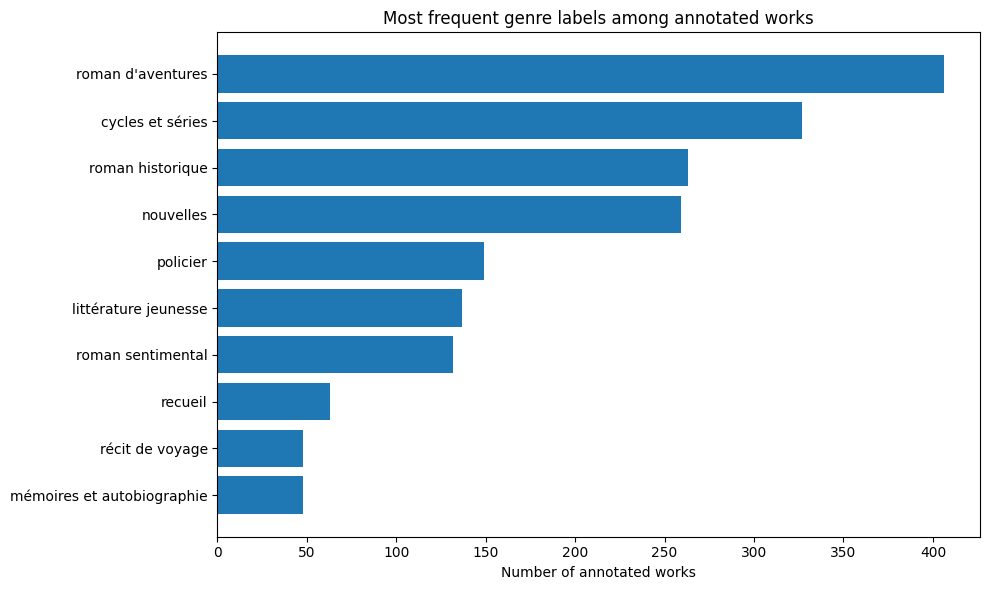

In [25]:
top10_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_genres["genre"],
    top10_genres["count"]
)

plt.gca().invert_yaxis()

plt.xlabel("Number of annotated works")
plt.title("Most frequent genre labels among annotated works")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_genres.png", dpi=300, bbox_inches="tight")

plt.show()

In [34]:
sorted(genre_labels.unique())

['cycles et séries',
 'fantastique',
 'fragments',
 'journal intime',
 'littérature jeunesse',
 'mémoires et autobiographie',
 'non-fiction',
 'nouvelles',
 'policier',
 'recueil',
 "roman d'aventures",
 'roman historique',
 'roman sentimental',
 'récit de voyage',
 'science-fiction',
 'épistolaire',
 'érotisme']

## 10. Conclusions

This notebook explored the structure of the *Corpus Chapitres* and extracted the bibliographic metadata required for the remainder of the thesis.

The corpus consists of TEI-encoded XML files. Metadata extraction identified publication dates, authors, author information, and available genre labels. A quality-control stage was used to identify and correct a small number of erroneous publication years while preserving the raw values for transparency.

The resulting metadata tables and descriptive statistics provide the basis for the preprocessing pipeline implemented in the following notebook and for the corpus description presented in Chapter 3.

## Files generated

This notebook generates the following files:

### Metadata

- `data/metadata/metadata_raw.csv`
- `data/metadata/metadata_audit.csv`
- `data/metadata/metadata.csv`

### Tables

- `results/tables/metadata_quality.csv`
- `results/tables/corpus_statistics.csv`
- `results/tables/novels_per_decade.csv`
- `results/tables/authors_per_decade.csv`
- `results/tables/genre_metadata_summary.csv`
- `results/tables/genre_counts.csv`

### Figures

- `results/figures/novels_per_decade.png`
- `results/figures/top_genres.png`